Content analysis (text, emoticons, image, audio, video) based social media analytics: Location analysis, Trend analysis, Hashtag popularity analysis, Sentiment analysis for given dataset, User engagement analysis. Analyze content types (text, emoticons, image, audio, video). Use techniques Sentiment analysis with Hugging face Transformers, Trend Analysis via time-series tools (e.g. Prophet) and Hashtag analysis using tools like hashtagify

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/SMA_DATASET/merged_comments.csv')

Location Analysis

                                                  id         text location  \
1  Just had a great workout at the gym! #fitnesslife     New York       NY   
2              Can't wait to go hiking this weekend!       Denver       CO   
3         Eating some delicious sushi for lunch #yum  Los Angeles       CA   
4     Watching the game with my buddies #sportsnight      Chicago       IL   
5  Excited to see my favorite band in concert ton...      Seattle       WA   

        state  
1    New York  
2    Colorado  
3  California  
4    Illinois  
5  Washington  


<ipython-input-73-f01d48043fab>:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette="rocket")


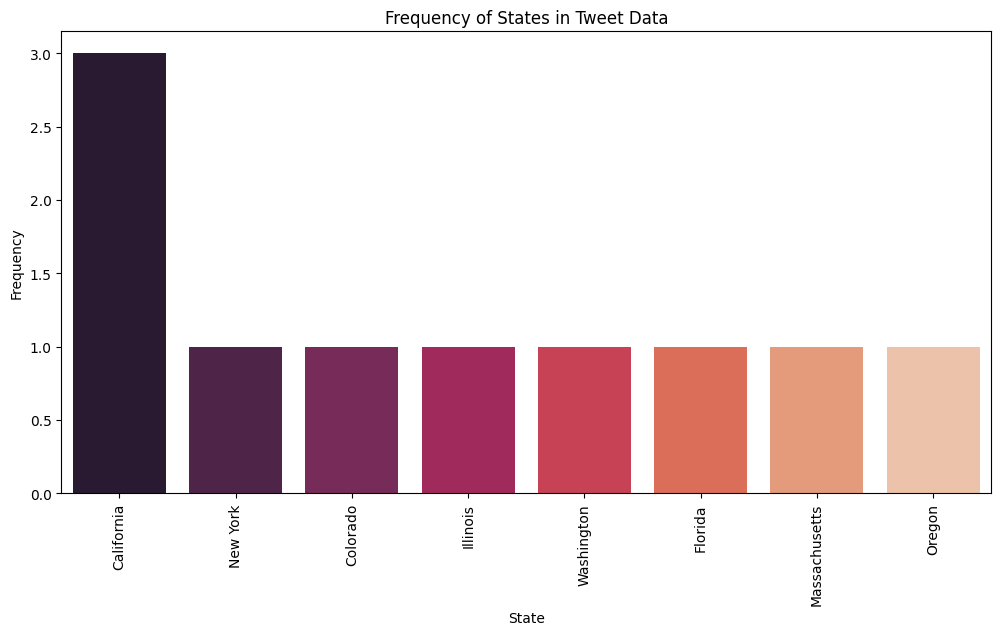

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/drive/MyDrive/SMA_DATASET/tweet_data.csv")
data = data.dropna()

states = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}


def get_state(location):
    words = location.split()
    for word in words:
        if word.upper() in states:
            return states[word.upper()]
    return None


data['state'] = data['location'].apply(get_state)
print(data.head())

state_counts = data['state'].value_counts()
plt.figure(figsize=(12, 6))

sns.barplot(x=state_counts.index, y=state_counts.values, palette="rocket")
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('Frequency of States in Tweet Data')
plt.show()


Trend analysis

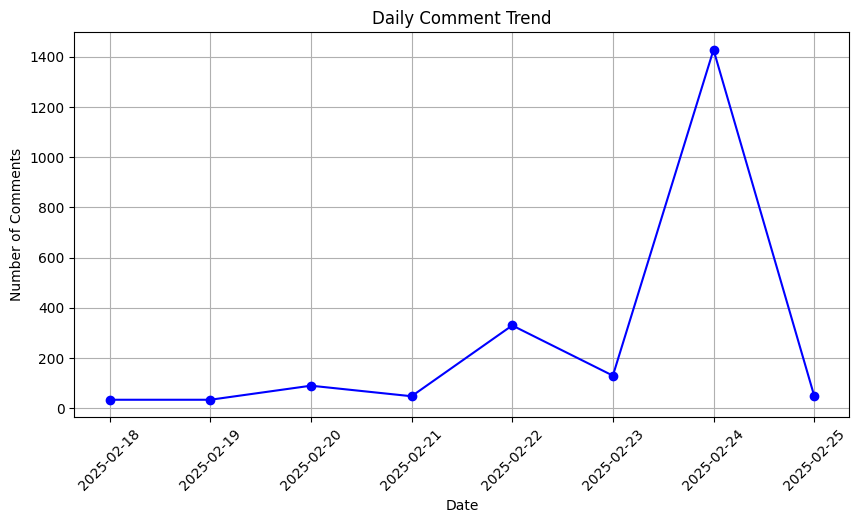

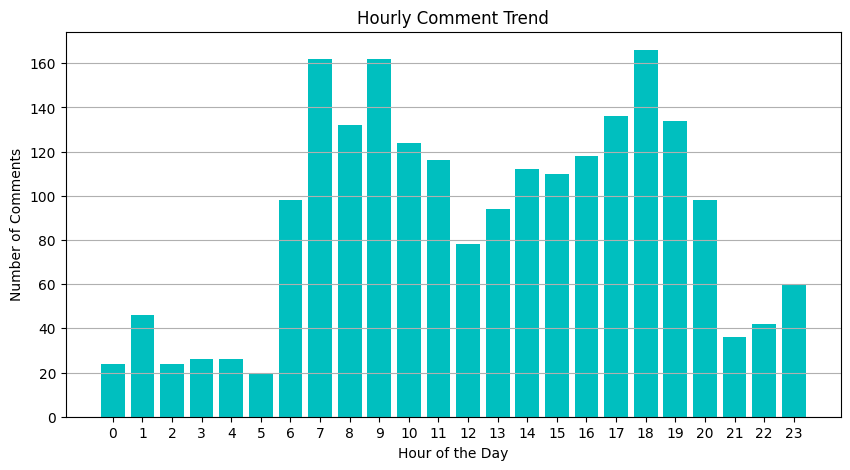

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
daily_trend = df.groupby(df['Date'].dt.date).size()

plt.figure(figsize=(10, 5))
plt.plot(daily_trend.index, daily_trend.values, marker='o', linestyle='-', color='b')
plt.xlabel('Date')
plt.ylabel('Number of Comments')
plt.title('Daily Comment Trend')
plt.xticks(rotation=45)
plt.grid()
plt.show()

print()

df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

hourly_trend = df.groupby(df['Time']).size()

plt.figure(figsize=(10, 5))
plt.bar(hourly_trend.index, hourly_trend.values, color='c')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Comments')
plt.title('Hourly Comment Trend')
plt.xticks(range(0, 24))
plt.grid(axis='y')
plt.show()

Hashtag popularity analysis

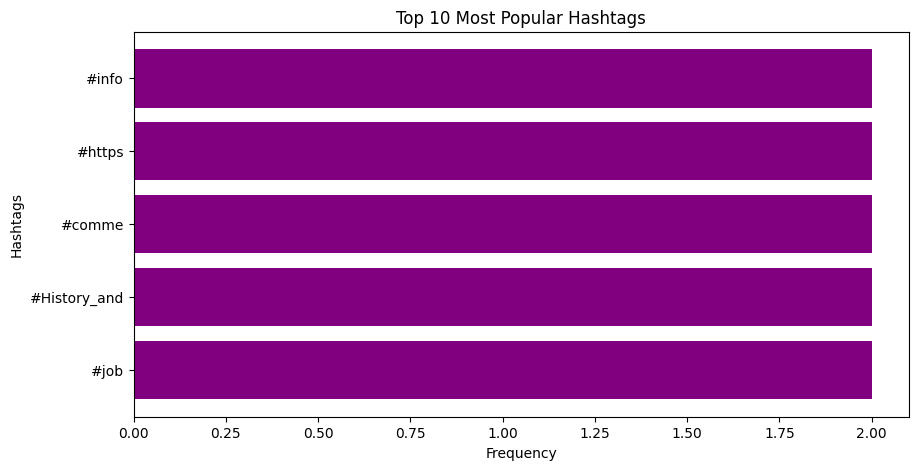

In [ ]:
import re
from collections import Counter


def extract_hashtags(text):
    return re.findall(r'#\w+', str(text))

df['Hashtags'] = df['Comment'].apply(extract_hashtags)
all_hashtags = [hashtag for hashtags in df['Hashtags'] for hashtag in hashtags]
hashtag_counts = Counter(all_hashtags)
hashtag_df = pd.DataFrame(hashtag_counts.items(), columns=['Hashtag', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(hashtag_df['Hashtag'][:10], hashtag_df['Count'][:10], color='purple')
plt.xlabel('Frequency')
plt.ylabel('Hashtags')
plt.title('Top 10 Most Popular Hashtags')
plt.gca().invert_yaxis()
plt.show()


Sentiment Analysis

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


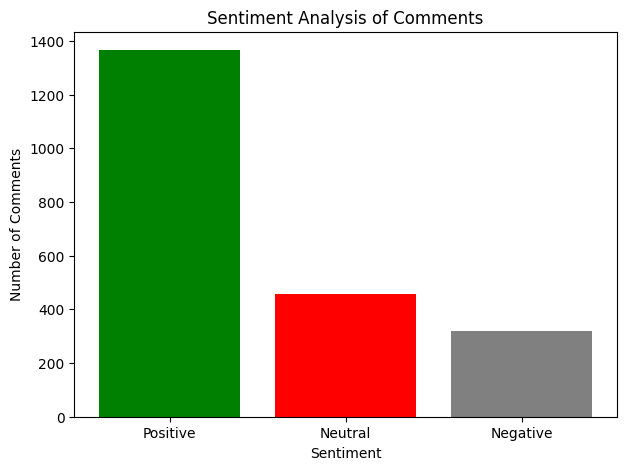

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Comment'].apply(get_sentiment)
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'gray'])
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.title('Sentiment Analysis of Comments')
plt.show()

User engagement analysis

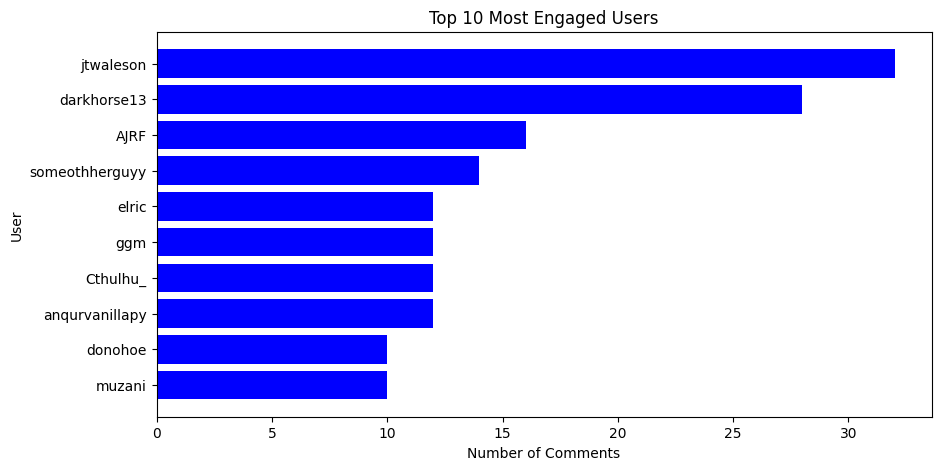

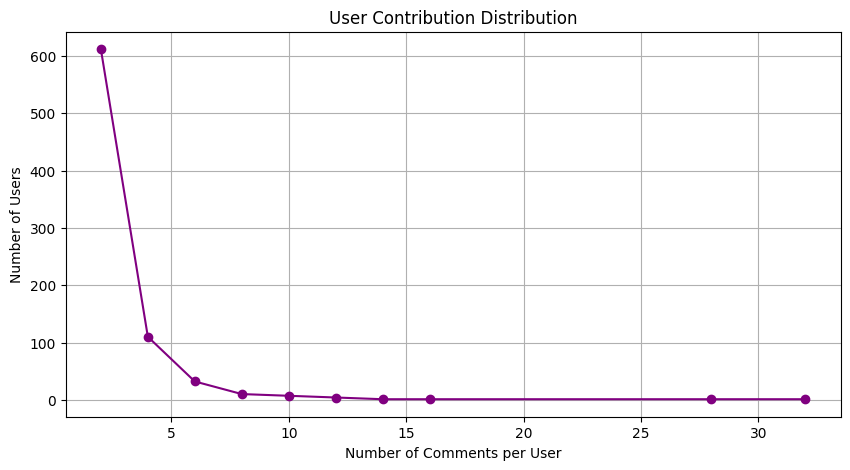

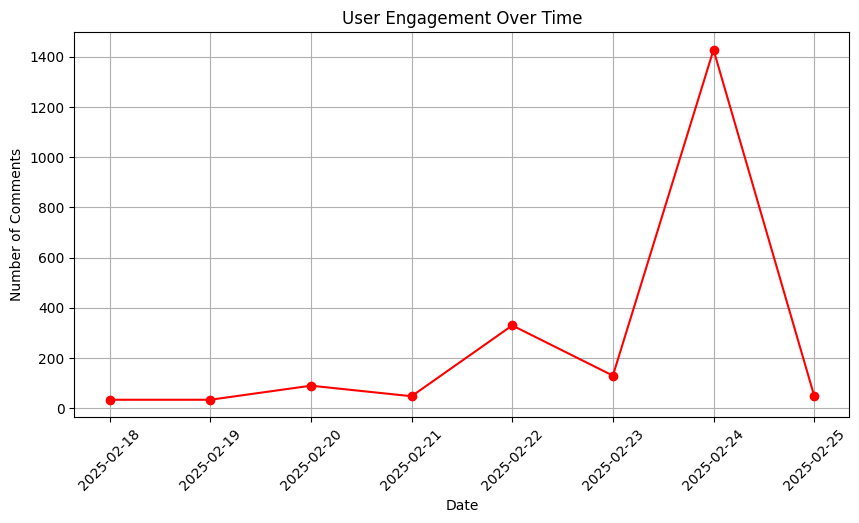

In [ ]:
user_engagement = df['Author'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(user_engagement.index, user_engagement.values, color='blue')
plt.xlabel('Number of Comments')
plt.ylabel('User')
plt.title('Top 10 Most Engaged Users')
plt.gca().invert_yaxis()
plt.show()

print()

user_comment_counts = df['Author'].value_counts()
comment_distribution = user_comment_counts.value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(comment_distribution.index, comment_distribution.values, marker='o', linestyle='-', color='purple')
plt.xlabel('Number of Comments per User')
plt.ylabel('Number of Users')
plt.title('User Contribution Distribution')
plt.grid()
plt.show()

print()

df['Date'] = pd.to_datetime(df['Date'])

daily_engagement = df.groupby(df['Date'].dt.date).size()

plt.figure(figsize=(10, 5))
plt.plot(daily_engagement.index, daily_engagement.values, marker='o', linestyle='-', color='red')
plt.xlabel('Date')
plt.ylabel('Number of Comments')
plt.title('User Engagement Over Time')
plt.xticks(rotation=45)
plt.grid()
plt.show()


Content Analysis

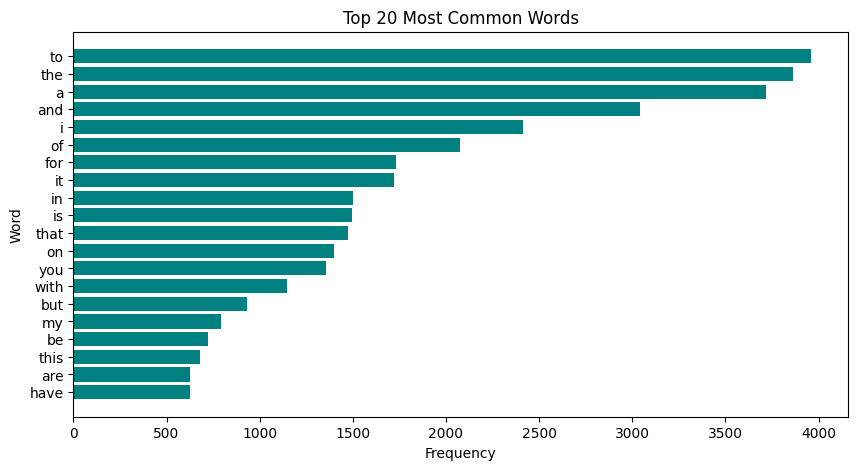

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

word_list = [word for comment in df['Comment'].dropna() for word in clean_text(comment)]
word_counts = Counter(word_list)
word_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(word_df['Word'][:20], word_df['Count'][:20], color='teal')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.title('Top 20 Most Common Words')
plt.gca().invert_yaxis()
plt.show()

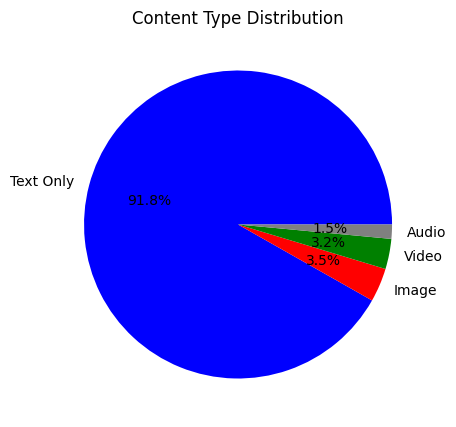

In [ ]:
image_keywords = ['image', 'photo', 'jpg', 'png']
video_keywords = ['video', 'mp4', 'youtube']
audio_keywords = ['audio', 'mp3', 'podcast']

def classify_content(text):
    text = str(text).lower()
    if any(word in text for word in image_keywords):
        return 'Image'
    elif any(word in text for word in video_keywords):
        return 'Video'
    elif any(word in text for word in audio_keywords):
        return 'Audio'
    else:
        return 'Text Only'

df['Content_Type'] = df['Comment'].apply(classify_content)

content_counts = df['Content_Type'].value_counts()

plt.figure(figsize=(7,5))
plt.pie(content_counts, labels=content_counts.index, autopct='%1.1f%%', colors=['blue', 'red', 'green', 'gray'])
plt.title('Content Type Distribution')
plt.show()


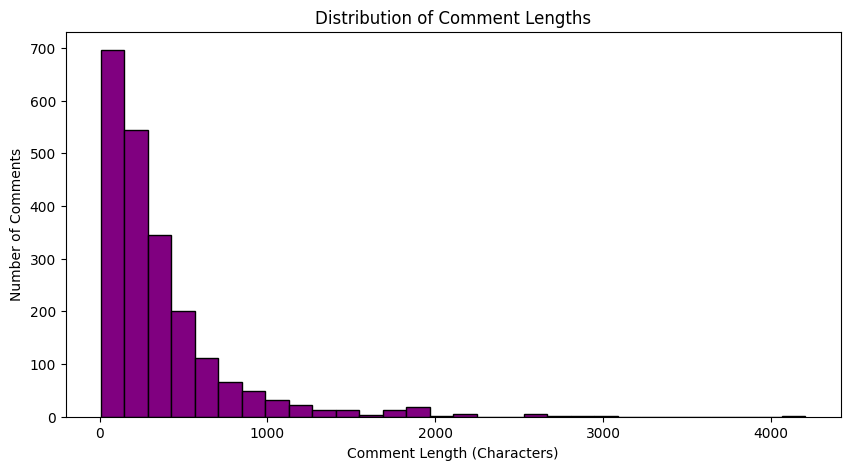

In [ ]:
df['Comment_Length'] = df['Comment'].astype(str).apply(len)

plt.figure(figsize=(10, 5))
plt.hist(df['Comment_Length'], bins=30, color='purple', edgecolor='black')
plt.xlabel('Comment Length (Characters)')
plt.ylabel('Number of Comments')
plt.title('Distribution of Comment Lengths')
plt.show()


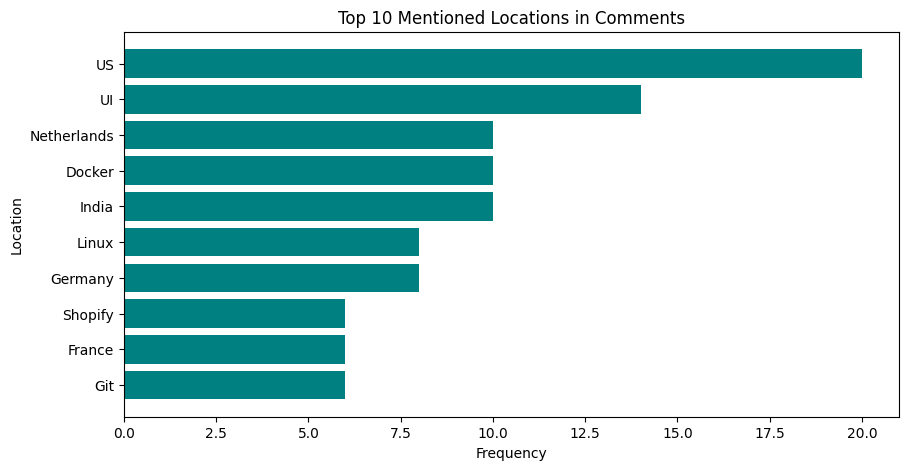

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')

def extract_locations(text):
    doc = nlp(str(text))
    return [ent.text for ent in doc.ents if ent.label_ == 'GPE']

df['Locations'] = df['Comment'].apply(extract_locations)
all_locations = [loc for locations in df['Locations'] for loc in locations]
location_counts = Counter(all_locations)
location_df = pd.DataFrame(location_counts.items(), columns=['Location', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(location_df['Location'][:10], location_df['Count'][:10], color='teal')
plt.xlabel('Frequency')
plt.ylabel('Location')
plt.title('Top 10 Mentioned Locations in Comments')
plt.gca().invert_yaxis()
plt.show()
